In [30]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 895.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.8 MB/s eta 0:00:00


In [1]:
!cd "/content/drive/MyDrive/AutoRetrain-NYC"

For data metadata pls look here : https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf

# Imports

In [53]:
import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from darts import TimeSeries
from darts.utils.statistics import check_seasonality
from darts.utils.model_selection import train_test_split

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLORS = {
    "blue": "#2563EB",
    "purple": "#7C3AED",
    "green": "#059669",
    "amber": "#F59E0B",
    "red": "#DC2626",
    "slate": "#475569",
    "light_blue": "#60A5FA",
}

In [9]:
prj_dir = "/content/drive/MyDrive/AutoRetrain-NYC"
data_dir = "/content/drive/MyDrive/AutoRetrain-NYC/Yellow_Taxi_Data_2026"

!ls "{data_dir}"

df = pd.read_parquet(f"{data_dir}/yellow_tripdata_2026-01.parquet")
df.head()

yellow_tripdata_2026-01.parquet  yellow_tripdata_2026-05.parquet
yellow_tripdata_2026-02.parquet  yellow_tripdata_2026-06.parquet
yellow_tripdata_2026-03.parquet  yellow_tripdata_2026-07.parquet
yellow_tripdata_2026-04.parquet


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [14]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/AutoRetrain-NYC")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FEATURE_DIR = PROJECT_DIR / "data" / "features"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data:", RAW_DIR)
print("Files:")
for f in sorted(RAW_DIR.glob("yellow_tripdata_2026-*.parquet")):
    print("  ", f.name)

Raw data: /content/drive/MyDrive/AutoRetrain-NYC/data/raw
Files:
   yellow_tripdata_2026-01.parquet
   yellow_tripdata_2026-02.parquet
   yellow_tripdata_2026-03.parquet
   yellow_tripdata_2026-04.parquet
   yellow_tripdata_2026-05.parquet
   yellow_tripdata_2026-06.parquet
   yellow_tripdata_2026-07.parquet


In [15]:
import os

file_info = []

for file in sorted(RAW_DIR.glob("yellow_tripdata_2026-*.parquet")):
    size_gb = os.path.getsize(file) / (1024 ** 3)

    file_info.append({
        "file": file.name,
        "size_gb": round(size_gb, 3)
    })

file_sizes = pd.DataFrame(file_info)
display(file_sizes)

print(f"\nTotal size: {file_sizes['size_gb'].sum():.2f} GB")

,file,size_gb
0,yellow_tripdata_2026-01.parquet,0.060
1,yellow_tripdata_2026-02.parquet,0.055
2,yellow_tripdata_2026-03.parquet,0.063
3,yellow_tripdata_2026-04.parquet,0.060
4,yellow_tripdata_2026-05.parquet,0.065
5,yellow_tripdata_2026-06.parquet,0.061
6,yellow_tripdata_2026-07.parquet,0.057



Total size: 0.42 GB


In [16]:
import pyarrow.parquet as pq

for file in sorted(RAW_DIR.glob("yellow_tripdata_2026-*.parquet")):

    parquet_file = pq.ParquetFile(file)

    print("=" * 80)
    print(file.name)
    print("Rows:", f"{parquet_file.metadata.num_rows:,}")
    print("Row groups:", parquet_file.metadata.num_row_groups)

    print("\nSchema:")
    print(parquet_file.schema_arrow)

yellow_tripdata_2026-01.parquet
Rows: 3,724,889
Row groups: 4

Schema:
VendorID: int32
tpep_pickup_datetime: timestamp[us]
tpep_dropoff_datetime: timestamp[us]
passenger_count: int64
trip_distance: double
RatecodeID: int64
store_and_fwd_flag: large_string
PULocationID: int32
DOLocationID: int32
payment_type: int64
fare_amount: double
extra: double
mta_tax: double
tip_amount: double
tolls_amount: double
improvement_surcharge: double
total_amount: double
congestion_surcharge: double
Airport_fee: double
cbd_congestion_fee: double
yellow_tripdata_2026-02.parquet
Rows: 3,399,866
Row groups: 4

Schema:
VendorID: int32
tpep_pickup_datetime: timestamp[us]
tpep_dropoff_datetime: timestamp[us]
passenger_count: int64
trip_distance: double
RatecodeID: int64
store_and_fwd_flag: large_string
PULocationID: int32
DOLocationID: int32
payment_type: int64
fare_amount: double
extra: double
mta_tax: double
tip_amount: double
tolls_amount: double
improvement_surcharge: double
total_amount: double
congestion

In [17]:
jan_file = RAW_DIR / "yellow_tripdata_2026-01.parquet"

jan = pd.read_parquet(jan_file)

print("Shape:", jan.shape)

display(jan.head())

Shape: (3724889, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [19]:
jan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [20]:
column_summary = pd.DataFrame({
    "dtype": jan.dtypes,
    "missing": jan.isna().sum(),
    "missing_pct": jan.isna().mean() * 100,
    "unique": jan.nunique()
})

column_summary = column_summary.sort_values(
    "missing_pct",
    ascending=False
)

display(column_summary)

,dtype,missing,missing_pct,unique
passenger_count,float64,1088058,29.210481,10
congestion_surcharge,float64,1088058,29.210481,3
store_and_fwd_flag,object,1088058,29.210481,2
RatecodeID,float64,1088058,29.210481,7
Airport_fee,float64,1088058,29.210481,8
tpep_dropoff_datetime,datetime64[us],0,0.000000,1755995
VendorID,int32,0,0.000000,4
tpep_pickup_datetime,datetime64[us],0,0.000000,1757191
DOLocationID,int32,0,0.000000,260
payment_type,int64,0,0.000000,5


In [21]:
display(jan.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
VendorID,3724889.0,NaN,NaN,NaN,1.873598,1.0,2.0,2.0,2.0,7.0,0.701458
tpep_pickup_datetime,3724889,NaN,NaN,NaN,2026-01-17 01:44:52.106518,2025-12-31 23:57:29,2026-01-09 17:51:59,2026-01-16 21:20:56,2026-01-24 07:25:11,2026-02-01 00:45:01,NaN
tpep_dropoff_datetime,3724889,NaN,NaN,NaN,2026-01-17 02:02:03.696138,2025-12-31 23:57:32,2026-01-09 18:08:47,2026-01-16 21:36:14,2026-01-24 07:40:22,2026-02-01 23:35:31,NaN
passenger_count,2636831.0,NaN,NaN,NaN,1.256271,0.0,1.0,1.0,1.0,9.0,0.670243
trip_distance,3724889.0,NaN,NaN,NaN,6.455647,0.0,1.0,1.81,3.73,269097.48,648.885528
RatecodeID,2636831.0,NaN,NaN,NaN,5.218853,1.0,1.0,1.0,1.0,99.0,19.653699
store_and_fwd_flag,2636831,2,N,2634494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PULocationID,3724889.0,NaN,NaN,NaN,161.43719,1.0,114.0,161.0,233.0,265.0,67.066574
DOLocationID,3724889.0,NaN,NaN,NaN,160.99357,1.0,107.0,162.0,234.0,265.0,71.03604
payment_type,3724889.0,NaN,NaN,NaN,0.846564,0.0,0.0,1.0,1.0,4.0,0.712049


In [22]:
time_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime"
]

for col in time_cols:
    print(col)
    print("dtype:", jan[col].dtype)
    print("min:", jan[col].min())
    print("max:", jan[col].max())
    print("missing:", jan[col].isna().sum())
    print()

tpep_pickup_datetime
dtype: datetime64[us]
min: 2025-12-31 23:57:29
max: 2026-02-01 00:45:01
missing: 0

tpep_dropoff_datetime
dtype: datetime64[us]
min: 2025-12-31 23:57:32
max: 2026-02-01 23:35:31
missing: 0



In [24]:
jan["trip_duration_min"] = (
    jan["tpep_dropoff_datetime"] -
    jan["tpep_pickup_datetime"]
).dt.total_seconds() / 60

jan["trip_duration_min"].describe(
    percentiles=[0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
)

,trip_duration_min
count,3.724889e+06
mean,1.719316e+01
std,2.517802e+01
min,-1.170000e+01
0.1%,0.000000e+00
1%,0.000000e+00
5%,3.283333e+00
25%,8.066667e+00
50%,1.336667e+01
75%,2.120000e+01


In [25]:
jan["trip_duration_min"].quantile(
    [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]
)

,trip_duration_min
0.000,-11.700000
0.001,0.000000
0.010,0.000000
0.050,3.283333
0.500,13.366667
0.950,42.750000
0.990,71.433333
0.999,125.785200
1.000,7507.900000


In [26]:
jan["trip_distance"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
)

print("Zero distance:", (jan["trip_distance"] == 0).sum())
print("Negative distance:", (jan["trip_distance"] < 0).sum())

Zero distance: 125738
Negative distance: 0


In [27]:
display(
    jan["passenger_count"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("count")
)

,count
passenger_count,
0.0,14787
1.0,2150994
2.0,334370
3.0,72864
4.0,49738
5.0,9184
6.0,4887
7.0,2
8.0,4


In [28]:
zone_columns = [
    "PULocationID",
    "DOLocationID"
]

for col in zone_columns:
    print("\n", col)
    print("Missing:", jan[col].isna().sum())
    print("Unique:", jan[col].nunique())
    print("Min:", jan[col].min())
    print("Max:", jan[col].max())


 PULocationID
Missing: 0
Unique: 262
Min: 1
Max: 265

 DOLocationID
Missing: 0
Unique: 260
Min: 1
Max: 265


In [29]:
print(
    "Pickup zones:",
    sorted(jan["PULocationID"].dropna().unique())[:20]
)

print(
    "Total pickup zones:",
    jan["PULocationID"].nunique()
)

Pickup zones: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20)]
Total pickup zones: 262


## Define months

In [32]:
MONTHS = [f"{m:02d}" for m in range(1, 8)]

MONTH_STARTS = {
    f"2026-{m:02d}": pd.Timestamp(f"2026-{m:02d}-01")
    for m in range(1, 8)
}

MONTH_ENDS = {
    month: start + pd.offsets.MonthBegin(1)
    for month, start in MONTH_STARTS.items()
}

print("Months:", MONTHS)
print("Month starts:", MONTH_STARTS)
print("Month ends:", MONTH_ENDS)

Months: ['01', '02', '03', '04', '05', '06', '07']
Month starts: {'2026-01': Timestamp('2026-01-01 00:00:00'), '2026-02': Timestamp('2026-02-01 00:00:00'), '2026-03': Timestamp('2026-03-01 00:00:00'), '2026-04': Timestamp('2026-04-01 00:00:00'), '2026-05': Timestamp('2026-05-01 00:00:00'), '2026-06': Timestamp('2026-06-01 00:00:00'), '2026-07': Timestamp('2026-07-01 00:00:00')}
Month ends: {'2026-01': Timestamp('2026-02-01 00:00:00'), '2026-02': Timestamp('2026-03-01 00:00:00'), '2026-03': Timestamp('2026-04-01 00:00:00'), '2026-04': Timestamp('2026-05-01 00:00:00'), '2026-05': Timestamp('2026-06-01 00:00:00'), '2026-06': Timestamp('2026-07-01 00:00:00'), '2026-07': Timestamp('2026-08-01 00:00:00')}


In [33]:
REQUIRED_COLUMNS = [
    "tpep_pickup_datetime",
    "PULocationID"
]

def aggregate_month(file_path):
    """
    Aggregate Yellow Taxi trips into hourly pickup demand by zone.
    Only the target calendar month is retained.
    """

    month = file_path.stem[-7:]  # e.g. 2026-01

    start = MONTH_STARTS[month]
    end = MONTH_ENDS[month]

    print(f"Processing {month}...")

    df = pd.read_parquet(
        file_path,
        columns=REQUIRED_COLUMNS
    )

    # Ensure datetime
    df["tpep_pickup_datetime"] = pd.to_datetime(
        df["tpep_pickup_datetime"]
    )

    # Keep only records belonging to this calendar month
    df = df[
        (df["tpep_pickup_datetime"] >= start) &
        (df["tpep_pickup_datetime"] < end)
    ]

    # Hourly aggregation by pickup zone
    hourly_zone = (
        df
        .assign(
            timestamp=df["tpep_pickup_datetime"].dt.floor("h")
        )
        .groupby(
            ["timestamp", "PULocationID"],
            observed=True
        )
        .size()
        .rename("demand")
        .reset_index()
    )

    print(f"  Raw rows retained: {len(df):,}")
    print(f"  Aggregated rows: {len(hourly_zone):,}")

    del df
    gc.collect()

    return hourly_zone

In [34]:
monthly_demand = []

for month in MONTHS:

    file_path = (
        RAW_DIR /
        f"yellow_tripdata_2026-{month}.parquet"
    )

    month_data = aggregate_month(file_path)

    monthly_demand.append(month_data)

    del month_data
    gc.collect()

Processing 2026-01...
  Raw rows retained: 3,724,882
  Aggregated rows: 123,598
Processing 2026-02...
  Raw rows retained: 3,399,850
  Aggregated rows: 112,267
Processing 2026-03...
  Raw rows retained: 3,952,432
  Aggregated rows: 123,383
Processing 2026-04...
  Raw rows retained: 3,831,228
  Aggregated rows: 116,571
Processing 2026-05...
  Raw rows retained: 4,090,822
  Aggregated rows: 120,535
Processing 2026-06...
  Raw rows retained: 3,837,231
  Aggregated rows: 97,719
Processing 2026-07...
  Raw rows retained: 3,530,063
  Aggregated rows: 100,480


In [35]:
hourly_zone_demand = pd.concat(
    monthly_demand,
    ignore_index=True
)

del monthly_demand
gc.collect()

hourly_zone_demand.head()

,timestamp,PULocationID,demand
0,2026-01-01,3,2
1,2026-01-01,4,78
2,2026-01-01,7,39
3,2026-01-01,9,3
4,2026-01-01,10,7


In [39]:
HOURLY_ZONE_PATH = (
    PROCESSED_DIR /
    "yellow_taxi_hourly_zone_demand_2026.parquet"
)

hourly_zone_demand.to_parquet(
    HOURLY_ZONE_PATH,
    index=False
)

print(HOURLY_ZONE_PATH)
print(
    f"Rows: {len(hourly_zone_demand):,}"
)

/content/drive/MyDrive/AutoRetrain-NYC/data/processed/yellow_taxi_hourly_zone_demand_2026.parquet
Rows: 794,553


In [40]:
hourly_zone_demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794553 entries, 0 to 794552
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   timestamp     794553 non-null  datetime64[us]
 1   PULocationID  794553 non-null  int32         
 2   demand        794553 non-null  int64         
dtypes: datetime64[us](1), int32(1), int64(1)
memory usage: 15.2 MB


In [45]:
display(hourly_zone_demand.describe().T)

,count,mean,min,25%,50%,75%,max,std
timestamp,794553,2026-04-12 13:42:05.613269,2026-01-01 00:00:00,2026-02-19 14:00:00,2026-04-10 18:00:00,2026-05-31 21:00:00,2026-07-31 23:00:00,NaN
PULocationID,794553.0,138.656713,1.0,73.0,141.0,210.0,265.0,76.326475
demand,794553.0,33.184077,1.0,2.0,5.0,25.0,964.0,68.717292


In [46]:
print(
    "Unique zones:",
    hourly_zone_demand["PULocationID"].nunique()
)

print(
    "Start:",
    hourly_zone_demand["timestamp"].min()
)

print(
    "End:",
    hourly_zone_demand["timestamp"].max()
)

print(
    "Total demand:",
    hourly_zone_demand["demand"].sum()
)

Unique zones: 262
Start: 2026-01-01 00:00:00
End: 2026-07-31 23:00:00
Total demand: 26366508


In [47]:
monthly_summary = (
    hourly_zone_demand
    .assign(
        month=hourly_zone_demand["timestamp"].dt.to_period("M")
    )
    .groupby("month")
    .agg(
        demand=("demand", "sum"),
        active_zones=("PULocationID", "nunique"),
        hourly_zone_records=("timestamp", "count")
    )
    .reset_index()
)

display(monthly_summary)

,month,demand,active_zones,hourly_zone_records
0,2026-01,3724882,262,123598
1,2026-02,3399850,259,112267
2,2026-03,3952432,261,123383
3,2026-04,3831228,261,116571
4,2026-05,4090822,259,120535
5,2026-06,3837231,258,97719
6,2026-07,3530063,260,100480


# NYC-wide hourly demand

In [50]:
nyc_hourly = (
    hourly_zone_demand
    .groupby("timestamp", as_index=False)
    .agg(
        demand=("demand", "sum")
    )
    .sort_values("timestamp")
)

nyc_hourly.head()

,timestamp,demand
0,2026-01-01 00:00:00,9294
1,2026-01-01 01:00:00,10254
2,2026-01-01 02:00:00,7853
3,2026-01-01 03:00:00,6529
4,2026-01-01 04:00:00,4108


In [51]:
expected_hours = pd.date_range(
    start=nyc_hourly["timestamp"].min(),
    end=nyc_hourly["timestamp"].max(),
    freq="h"
)

actual_hours = pd.DatetimeIndex(
    nyc_hourly["timestamp"]
)

missing_hours = expected_hours.difference(actual_hours)

print(
    "Expected hours:",
    len(expected_hours)
)

print(
    "Actual hours:",
    len(actual_hours)
)

print(
    "Missing hours:",
    len(missing_hours)
)

Expected hours: 5088
Actual hours: 5087
Missing hours: 1


In [54]:
series = TimeSeries.from_dataframe(
    nyc_hourly,
    time_col="timestamp",
    value_cols="demand",
    freq="h"
)

print(series)
print("\nStart:", series.start_time())
print("End:", series.end_time())
print("Length:", len(series))

                      demand
timestamp                   
2026-01-01 00:00:00   9294.0
2026-01-01 01:00:00  10254.0
2026-01-01 02:00:00   7853.0
2026-01-01 03:00:00   6529.0
2026-01-01 04:00:00   4108.0
...                      ...
2026-07-31 19:00:00   7145.0
2026-07-31 20:00:00   6822.0
2026-07-31 21:00:00   6443.0
2026-07-31 22:00:00   6871.0
2026-07-31 23:00:00   7132.0

shape: (5088, 1, 1), freq: h, size: 39.75 KB

Start: 2026-01-01 00:00:00
End: 2026-07-31 23:00:00
Length: 5088


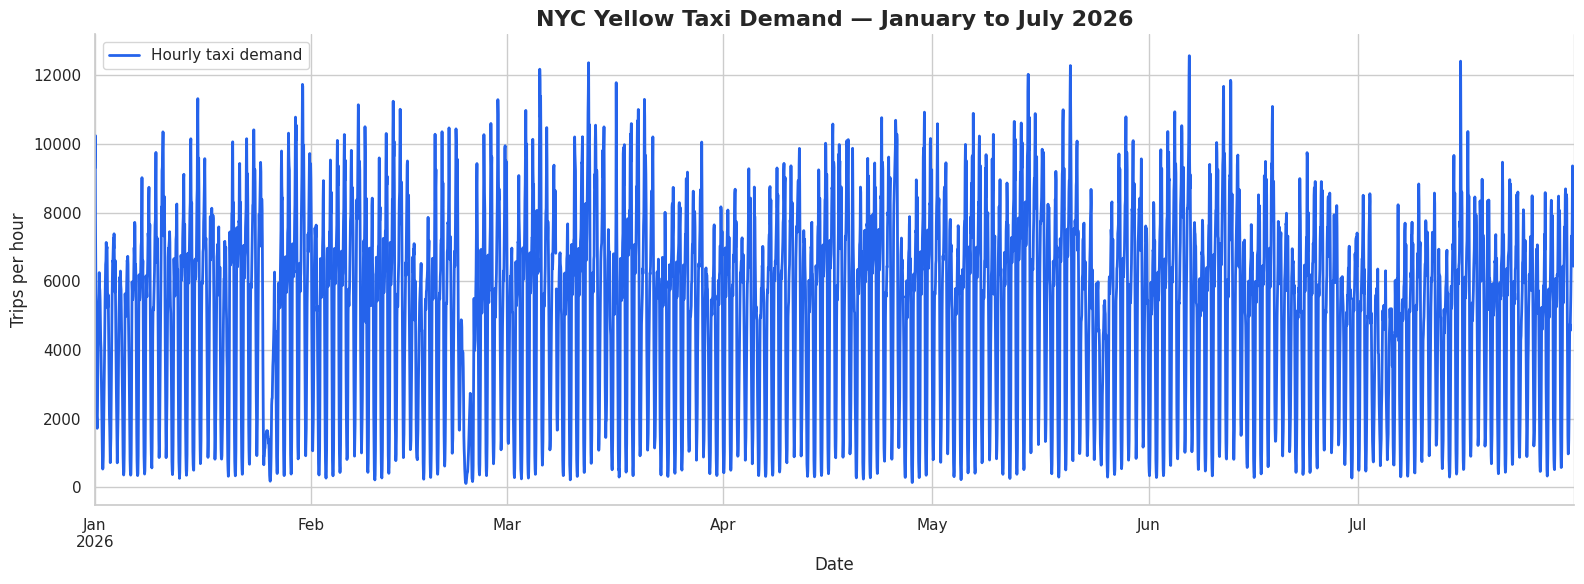

In [56]:
# Overall Demand

fig, ax = plt.subplots(figsize=(16, 6))

series.plot(
    ax=ax,
    label="Hourly taxi demand",
    color=COLORS["blue"]
)

ax.set_title(
    "NYC Yellow Taxi Demand — January to July 2026",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Trips per hour")

ax.legend()

plt.tight_layout()
plt.show()

In [60]:
# Daily demand
daily_demand = (nyc_hourly
                .set_index("timestamp")["demand"]
                .resample("D")
                .sum())
display(daily_demand.head())

,demand
timestamp,
2026-01-01,114466
2026-01-02,100054
2026-01-03,108632
2026-01-04,93622
2026-01-05,96951


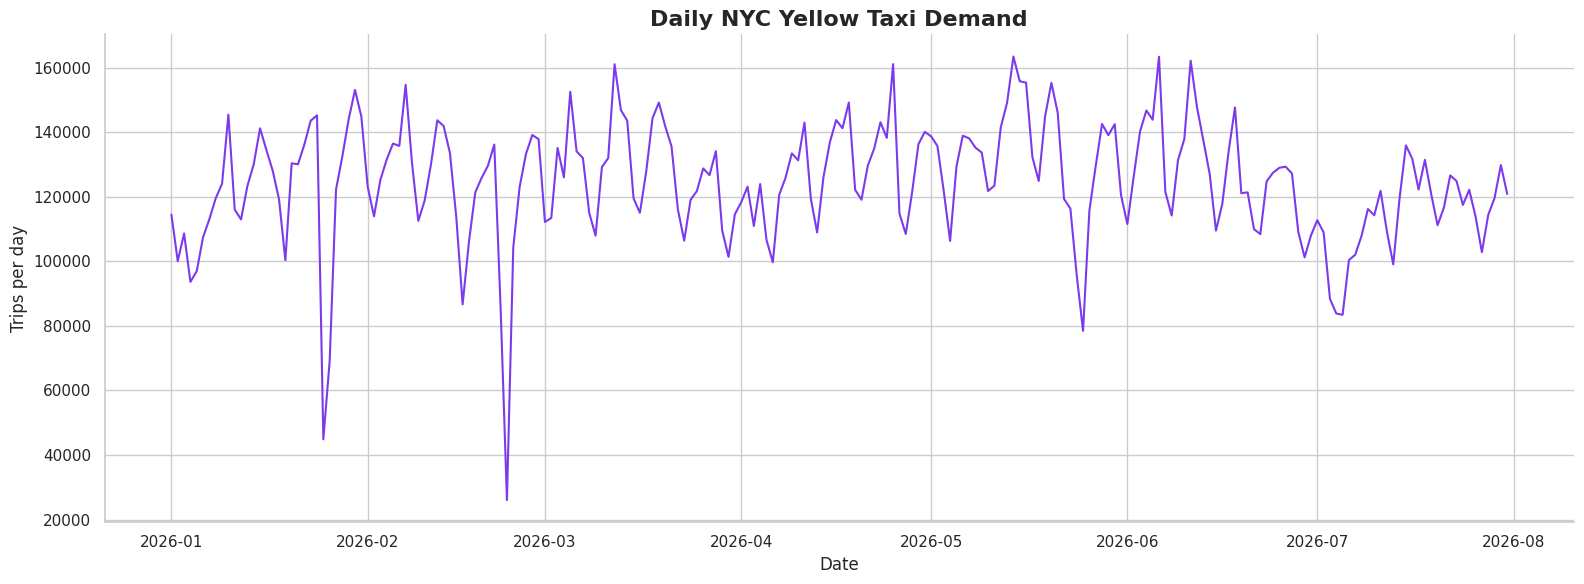

In [61]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    daily_demand.index,
    daily_demand.values,
    linewidth=1.5,
    color=COLORS["purple"]
)

ax.set_title(
    "Daily NYC Yellow Taxi Demand",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Trips per day")

plt.tight_layout()
plt.show()

In [64]:
# monthly demand
monthly_demand = (nyc_hourly
                .set_index("timestamp")["demand"]
                .resample("M")
                .sum())
display(monthly_demand.head(7))

,demand
timestamp,
2026-01-31,3724882
2026-02-28,3399850
2026-03-31,3952432
2026-04-30,3831228
2026-05-31,4090822
2026-06-30,3837231
2026-07-31,3530063


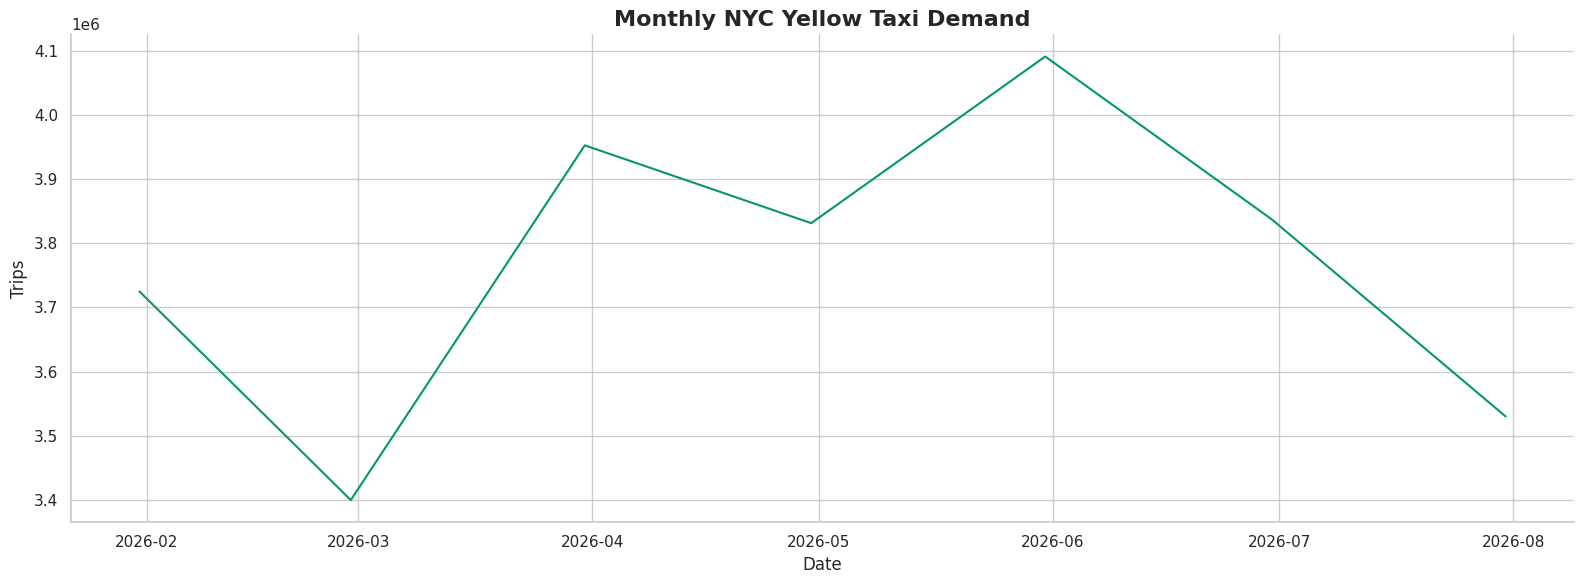

In [65]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    monthly_demand.index,
    monthly_demand.values,
    linewidth=1.5,
    color=COLORS["green"]
)

ax.set_title(
    "Monthly NYC Yellow Taxi Demand",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Trips")

plt.tight_layout()
plt.show()

## rolling statistics

In [67]:
daily_stats = pd.DataFrame({
    "demand": daily_demand,
    "rolling_mean_7d": daily_demand.rolling(7).mean(),
    "rolling_std_7d": daily_demand.rolling(7).std()
})

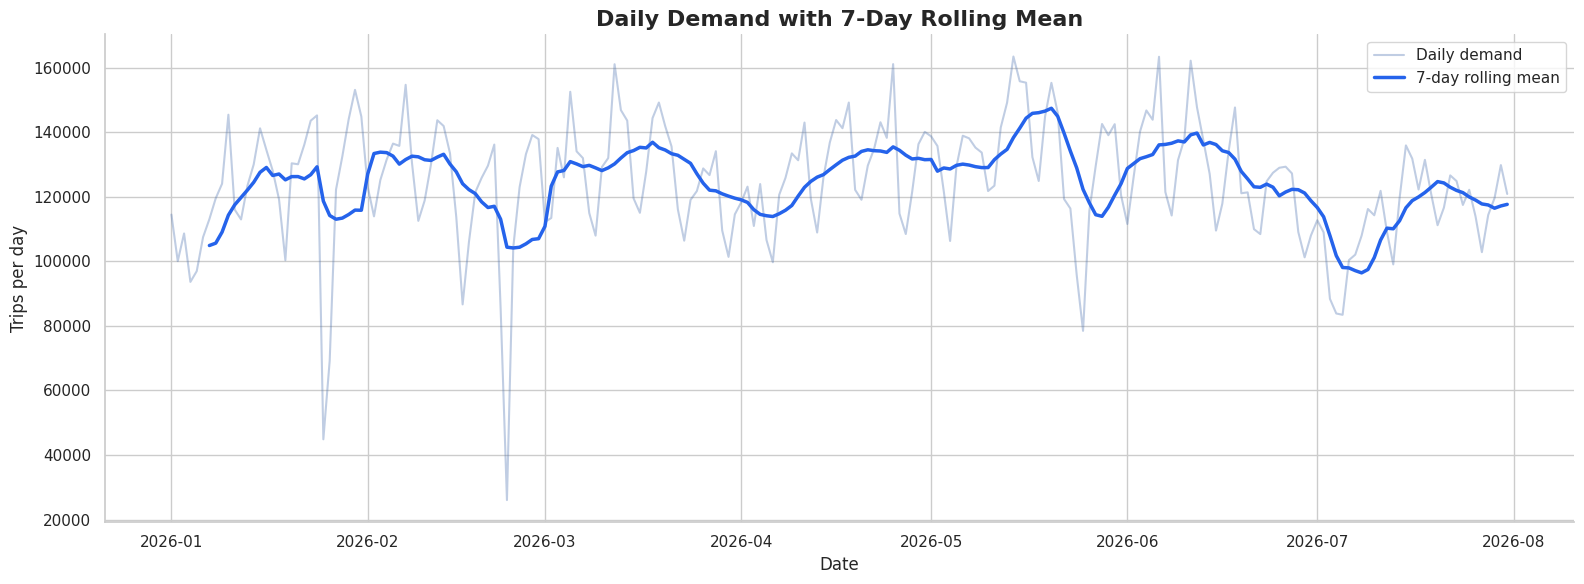

In [68]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    daily_stats.index,
    daily_stats["demand"],
    alpha=0.35,
    label="Daily demand"
)

ax.plot(
    daily_stats.index,
    daily_stats["rolling_mean_7d"],
    linewidth=2.5,
    color=COLORS["blue"],
    label="7-day rolling mean"
)

ax.set_title(
    "Daily Demand with 7-Day Rolling Mean",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Trips per day")

ax.legend()

plt.tight_layout()
plt.show()

In [69]:
# hour-of-day seasonality

eda_df = nyc_hourly.copy()

eda_df["hour"] = eda_df["timestamp"].dt.hour
eda_df["day_of_week"] = eda_df["timestamp"].dt.dayofweek

display(eda_df.head())

,timestamp,demand,hour,day_of_week
0,2026-01-01 00:00:00,9294,0,3
1,2026-01-01 01:00:00,10254,1,3
2,2026-01-01 02:00:00,7853,2,3
3,2026-01-01 03:00:00,6529,3,3
4,2026-01-01 04:00:00,4108,4,3


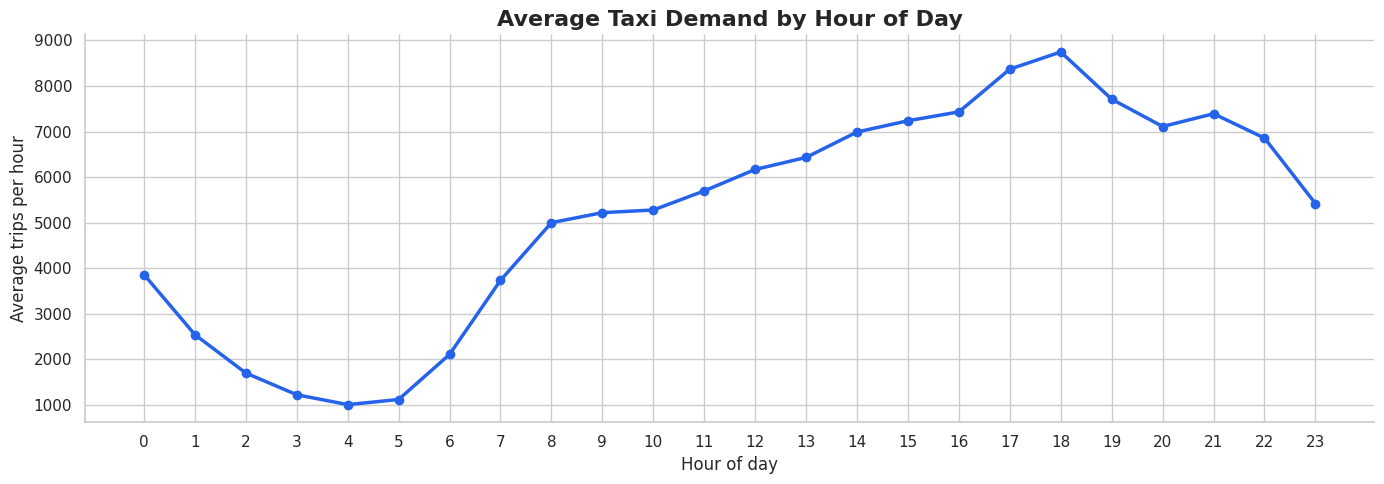

In [70]:
hour_profile = (
    eda_df
    .groupby("hour")["demand"]
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    hour_profile.index,
    hour_profile.values,
    marker="o",
    linewidth=2.5,
    color=COLORS["blue"]
)

ax.set_title(
    "Average Taxi Demand by Hour of Day",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Average trips per hour")

ax.set_xticks(range(24))

plt.tight_layout()
plt.show()

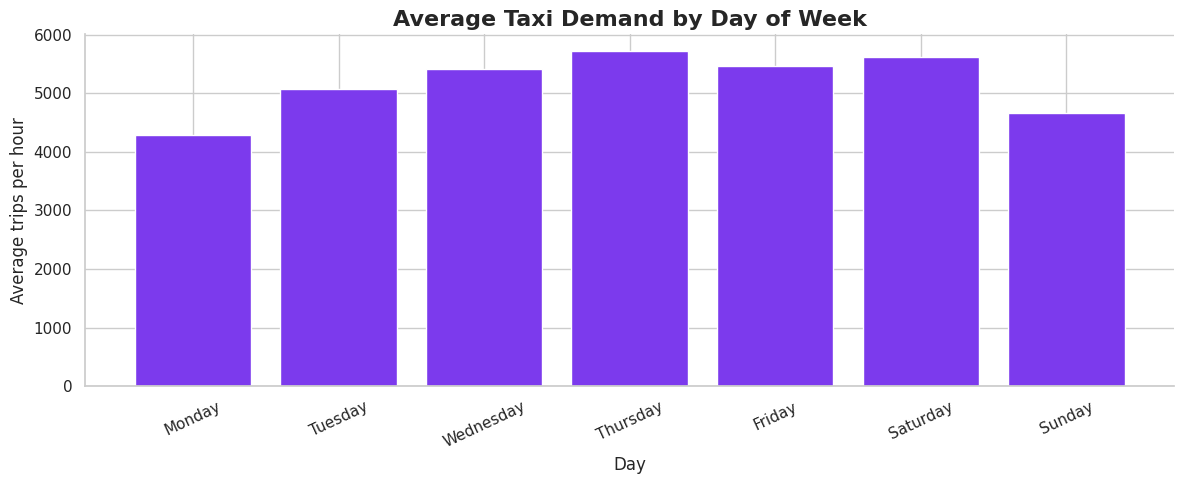

In [71]:
dow_profile = (
    eda_df
    .groupby("day_of_week")["demand"]
    .mean()
)

dow_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    dow_names,
    dow_profile.values,
    color=COLORS["purple"]
)

ax.set_title(
    "Average Taxi Demand by Day of Week",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Day")
ax.set_ylabel("Average trips per hour")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

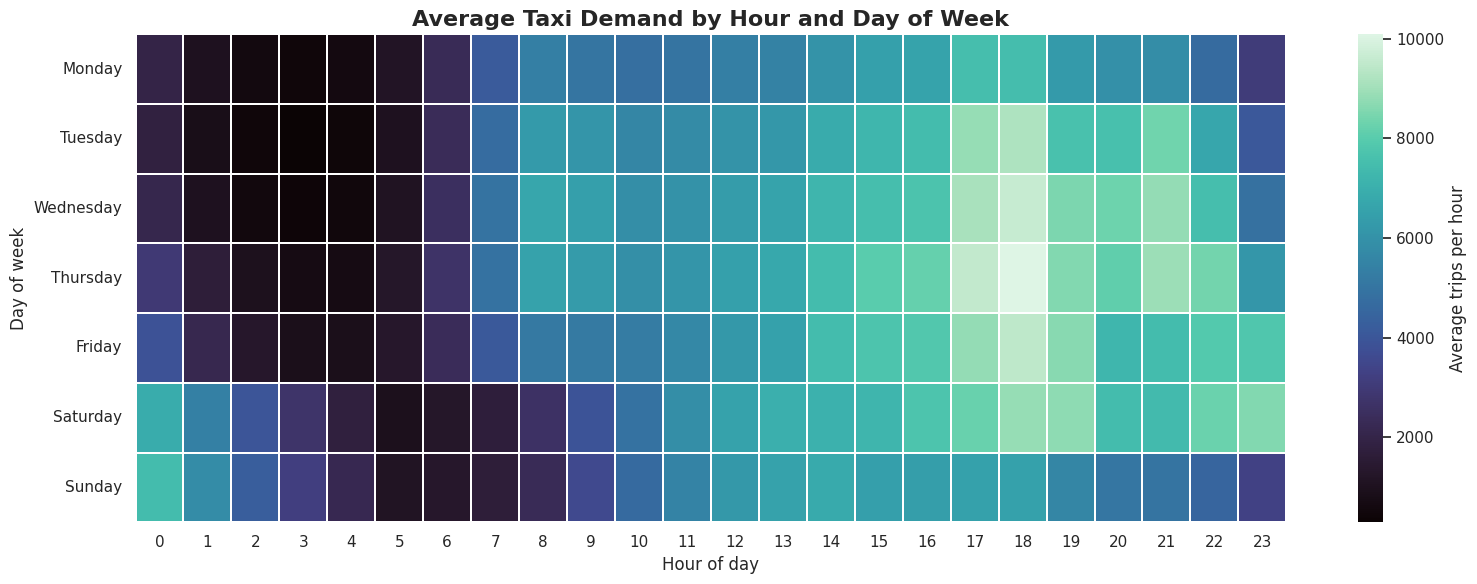

In [72]:
# hour × weekday heatmap
eda_df["day_name"] = eda_df["timestamp"].dt.day_name()

heatmap_data = (
    eda_df
    .pivot_table(
        index="day_name",
        columns="hour",
        values="demand",
        aggfunc="mean"
    )
    .reindex(dow_names)
)

plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    cmap="mako",
    linewidths=0.2,
    cbar_kws={
        "label": "Average trips per hour"
    }
)

plt.title(
    "Average Taxi Demand by Hour and Day of Week",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour of day")
plt.ylabel("Day of week")

plt.tight_layout()
plt.show()

In [82]:
print("Missing hours:", len(missing_hours))

if len(missing_hours) > 0:
    display(missing_hours)

    # Group missing hours by date to spot whole-day gaps vs scattered ones
    missing_by_date = (
        pd.Series(missing_hours)
        .dt.date
        .value_counts()
        .sort_index()
    )
    print("\nMissing hours per date:")
    display(missing_by_date)

Missing hours: 1


DatetimeIndex(['2026-03-08 02:00:00'], dtype='datetime64[ns]', freq='h')


Missing hours per date:


,count
2026-03-08,1


In [83]:
nyc_hourly_full = (
    nyc_hourly
    .set_index("timestamp")
    .reindex(expected_hours)
    .rename_axis("timestamp")
)

nyc_hourly_full["was_missing"] = nyc_hourly_full["demand"].isna()

print("Filled-in rows:", nyc_hourly_full["was_missing"].sum())

# Interpolate gaps (better than ffill for a seasonal series — preserves local trend)
nyc_hourly_full["demand"] = nyc_hourly_full["demand"].interpolate(method="linear")

nyc_hourly_full = nyc_hourly_full.reset_index()

Filled-in rows: 1


In [84]:
series = TimeSeries.from_dataframe(
    nyc_hourly_full,
    time_col="timestamp",
    value_cols="demand",
    freq="h"
)

print(series)
print("\nStart:", series.start_time())
print("End:", series.end_time())
print("Length:", len(series))

                      demand
timestamp                   
2026-01-01 00:00:00   9294.0
2026-01-01 01:00:00  10254.0
2026-01-01 02:00:00   7853.0
2026-01-01 03:00:00   6529.0
2026-01-01 04:00:00   4108.0
...                      ...
2026-07-31 19:00:00   7145.0
2026-07-31 20:00:00   6822.0
2026-07-31 21:00:00   6443.0
2026-07-31 22:00:00   6871.0
2026-07-31 23:00:00   7132.0

shape: (5088, 1, 1), freq: h, size: 39.75 KB

Start: 2026-01-01 00:00:00
End: 2026-07-31 23:00:00
Length: 5088


In [85]:
# 24-hour seasonality
daily_seasonality, daily_period = check_seasonality(
    series,
    m=24,
    max_lag=168
)

print("Daily seasonality detected:", daily_seasonality)
print("Detected period:", daily_period)

# Weekly seasonality
weekly_seasonality, weekly_period = check_seasonality(
    series,
    m=168,
    max_lag=336
)

print("Weekly seasonality detected:", weekly_seasonality)
print("Detected period:", weekly_period)

Daily seasonality detected: True
Detected period: 24
Weekly seasonality detected: True
Detected period: 168


<Figure size 1400x600 with 0 Axes>

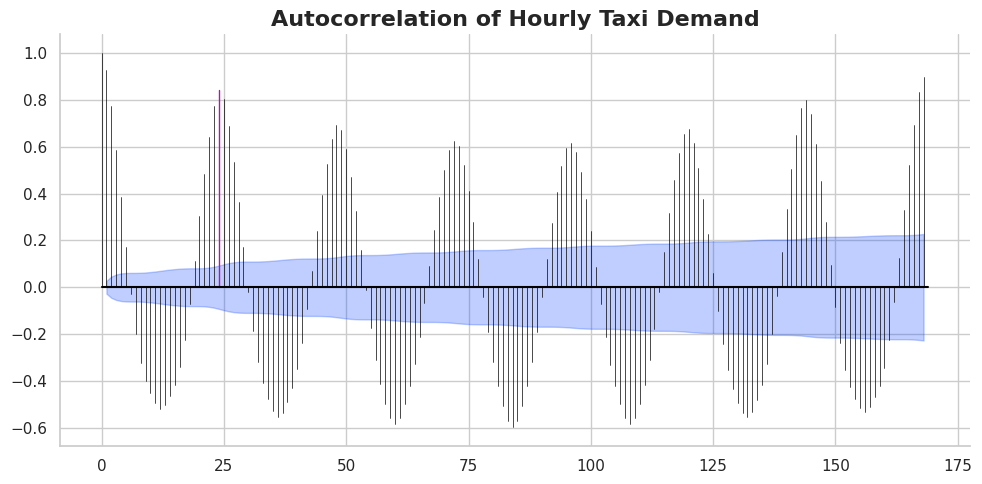

In [86]:
from darts.utils.statistics import plot_acf

plt.figure(figsize=(14, 6))

plot_acf(
    series,
    m=24,
    max_lag=168
)

plt.title(
    "Autocorrelation of Hourly Taxi Demand",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

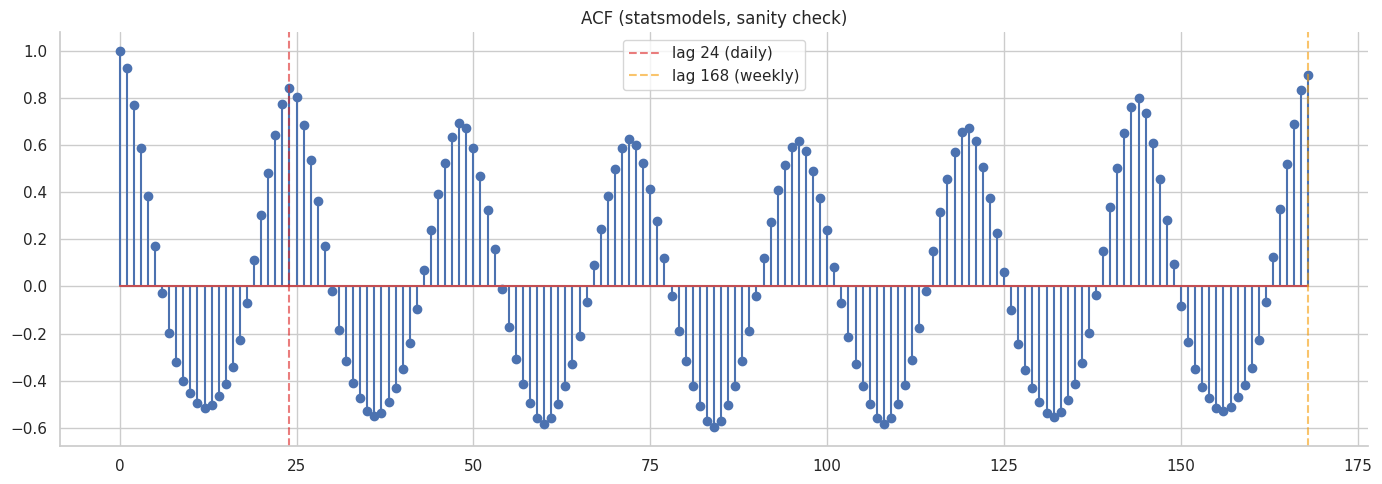

In [87]:
from statsmodels.tsa.stattools import acf as sm_acf

acf_vals = sm_acf(series.values().flatten(), nlags=168, fft=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.stem(range(len(acf_vals)), acf_vals)
ax.axvline(24, color=COLORS["red"], linestyle="--", alpha=0.6, label="lag 24 (daily)")
ax.axvline(168, color=COLORS["amber"], linestyle="--", alpha=0.6, label="lag 168 (weekly)")
ax.set_title("ACF (statsmodels, sanity check)")
ax.legend()
plt.tight_layout()
plt.show()

,total_demand,mean_hourly_demand,std_hourly_demand
timestamp,,,
2026-01-01,3724882,5006.561828,2853.921825
2026-02-01,3399850,5059.300595,2933.735318
2026-03-01,3952432,5319.558546,2901.308281
2026-04-01,3831228,5321.150000,2870.087309
2026-05-01,4090822,5498.416667,2913.142909
2026-06-01,3837231,5329.487500,2772.364041
2026-07-01,3530063,4744.708333,2459.686113


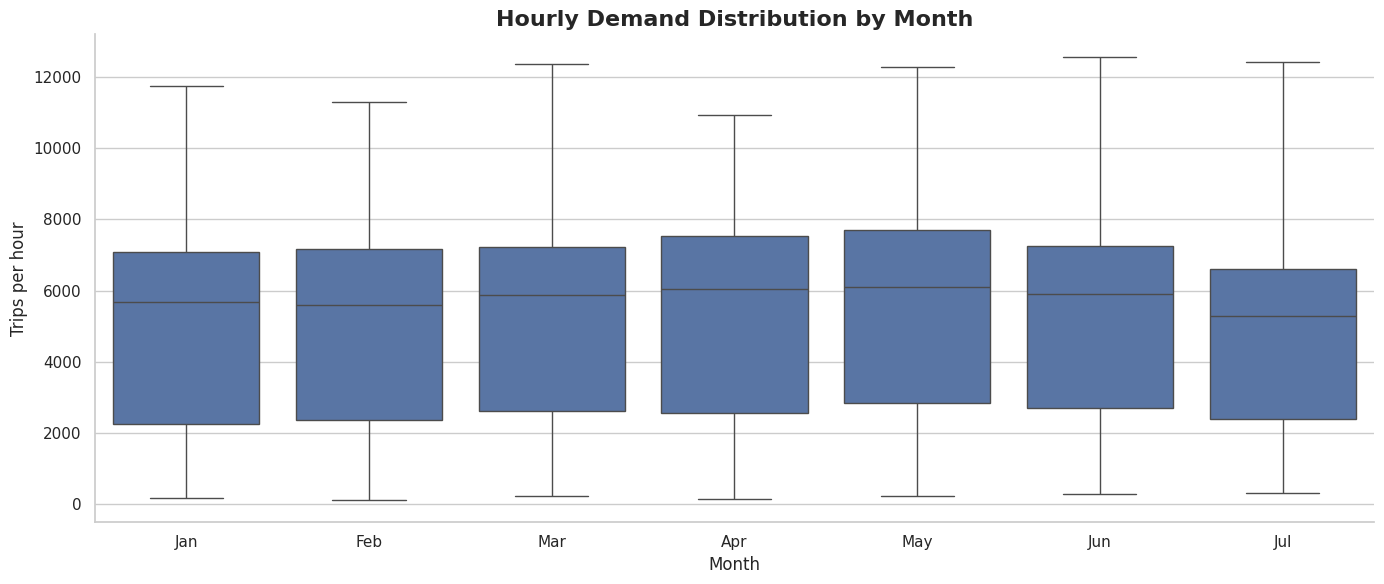

In [88]:
monthly_nyc = (
    nyc_hourly
    .set_index("timestamp")["demand"]
    .resample("MS")
    .agg(
        total_demand="sum",
        mean_hourly_demand="mean",
        std_hourly_demand="std"
    )
)

display(monthly_nyc)

eda_df["month"] = eda_df["timestamp"].dt.strftime("%b")

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=eda_df,
    x="month",
    y="demand",
    order=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"]
)

plt.title(
    "Hourly Demand Distribution by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Trips per hour")

plt.tight_layout()
plt.show()

In [89]:
q1 = nyc_hourly["demand"].quantile(0.25)
q3 = nyc_hourly["demand"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = nyc_hourly[
    (nyc_hourly["demand"] < lower_bound) |
    (nyc_hourly["demand"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Outlier observations:", len(outliers))

Q1: 2520.5
Q3: 7215.5
IQR: 4695.0
Lower bound: -4522.0
Upper bound: 14258.0
Outlier observations: 0


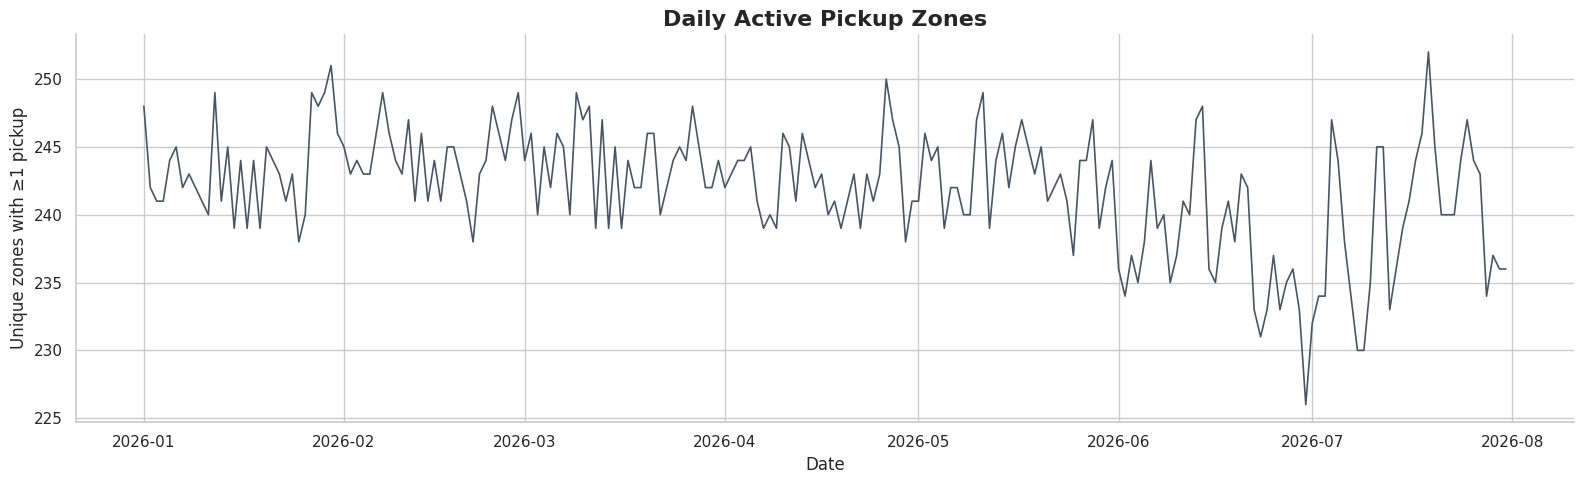

Total unique zones (whole period): 262
Min daily active zones: 226
Max daily active zones: 252


In [90]:
# Daily active zones (unique pickup zones per day)
daily_zones = (
    hourly_zone_demand
    .assign(date=hourly_zone_demand["timestamp"].dt.date)
    .groupby("date")["PULocationID"]
    .nunique()
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_zones.index, daily_zones.values, linewidth=1.2, color=COLORS["slate"])
ax.set_title("Daily Active Pickup Zones", fontsize=16, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Unique zones with ≥1 pickup")
plt.tight_layout()
plt.show()

print("Total unique zones (whole period):", hourly_zone_demand["PULocationID"].nunique())
print("Min daily active zones:", daily_zones.min())
print("Max daily active zones:", daily_zones.max())

Top 10 zones by total demand:


,demand
PULocationID,
237,1178934
161,1086259
236,1063128
132,1029015
162,801546
186,787421
142,762569
230,756126
79,694079



Top 10 zones = 33.5% of total demand
Top 20 zones = 56.8% of total demand
Zones needed for 80% of demand: 35


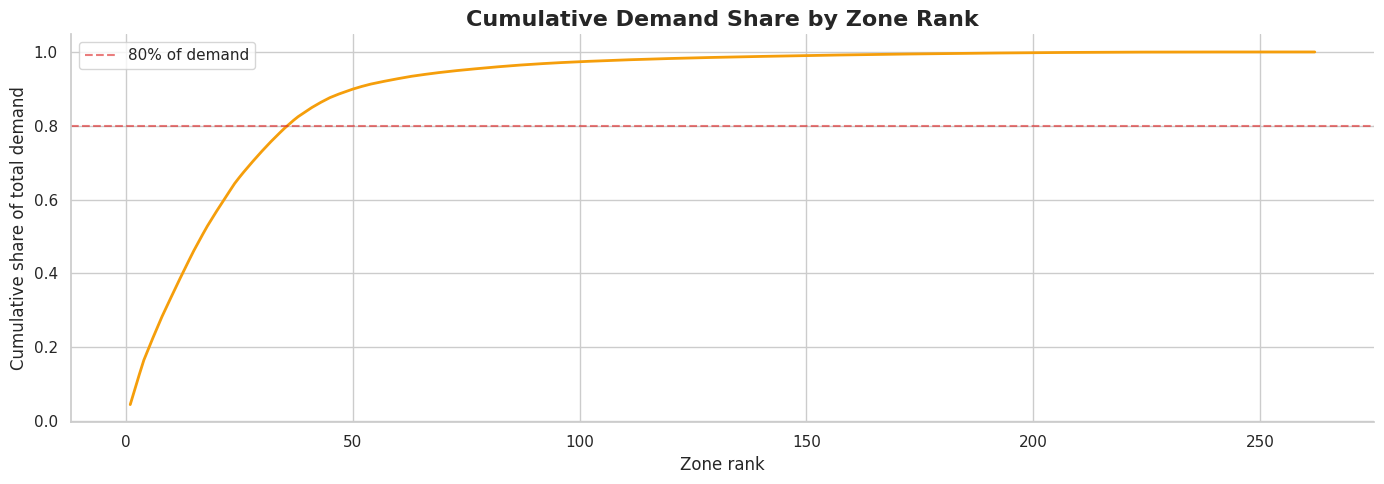

In [91]:
# Zone-level total demand — concentration / Pareto check
zone_totals = (
    hourly_zone_demand
    .groupby("PULocationID")["demand"]
    .sum()
    .sort_values(ascending=False)
)

zone_share = zone_totals / zone_totals.sum()
zone_cumshare = zone_share.cumsum()

print("Top 10 zones by total demand:")
display(zone_totals.head(10))

print(f"\nTop 10 zones = {zone_cumshare.iloc[9]*100:.1f}% of total demand")
print(f"Top 20 zones = {zone_cumshare.iloc[19]*100:.1f}% of total demand")
print(f"Zones needed for 80% of demand: {(zone_cumshare <= 0.8).sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(1, len(zone_cumshare) + 1), zone_cumshare.values, color=COLORS["amber"], linewidth=2)
ax.axhline(0.8, color=COLORS["red"], linestyle="--", alpha=0.6, label="80% of demand")
ax.set_title("Cumulative Demand Share by Zone Rank", fontsize=16, fontweight="bold")
ax.set_xlabel("Zone rank")
ax.set_ylabel("Cumulative share of total demand")
ax.legend()
plt.tight_layout()
plt.show()

In [92]:
# Low-activity / long-tail zones — candidates to exclude or bucket as "other" later
zone_hourly_counts = (
    hourly_zone_demand
    .groupby("PULocationID")
    .size()
    .rename("active_hours")
)

low_activity = zone_hourly_counts[zone_hourly_counts < zone_hourly_counts.quantile(0.1)]
print(f"Zones in bottom 10% of active hours: {len(low_activity)}")
display(zone_hourly_counts.sort_values().head(15))

Zones in bottom 10% of active hours: 27


,active_hours
PULocationID,
99,4
105,7
204,10
5,15
199,15
44,22
84,23
187,47
2,54


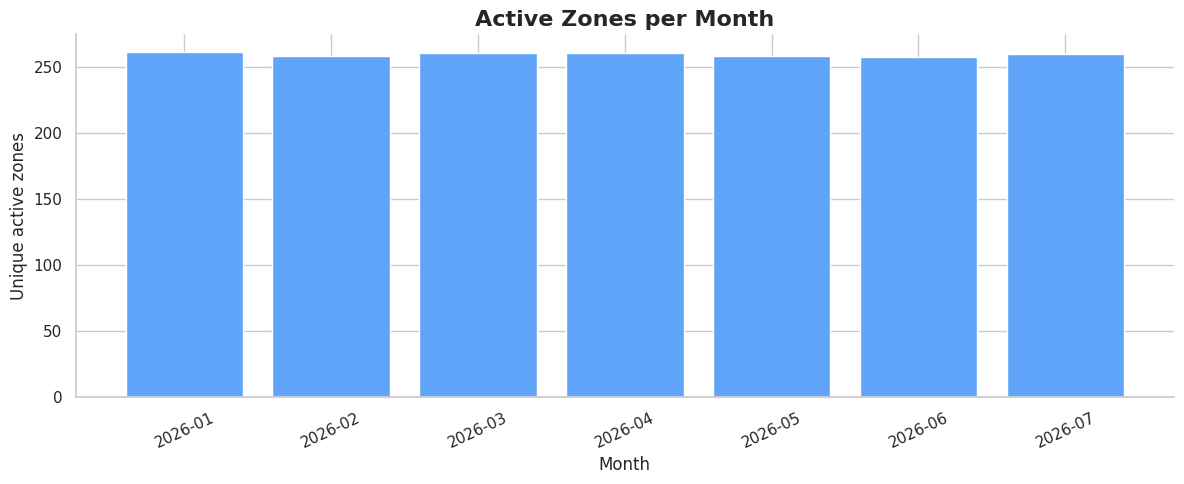

In [93]:
# Active zones by month (from your existing monthly_summary, just visualized)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_summary["month"].astype(str), monthly_summary["active_zones"], color=COLORS["light_blue"])
ax.set_title("Active Zones per Month", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Unique active zones")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [94]:
NYC_HOURLY_FULL_PATH = (
    PROCESSED_DIR /
    "nyc_hourly_demand_gapfilled_2026.parquet"
)

nyc_hourly_full.to_parquet(
    NYC_HOURLY_FULL_PATH,
    index=False
)

print(NYC_HOURLY_FULL_PATH)
print(f"Rows: {len(nyc_hourly_full):,}")
print(f"Interpolated rows: {nyc_hourly_full['was_missing'].sum():,}")
print(f"Date range: {nyc_hourly_full['timestamp'].min()} → {nyc_hourly_full['timestamp'].max()}")

/content/drive/MyDrive/AutoRetrain-NYC/data/processed/nyc_hourly_demand_gapfilled_2026.parquet
Rows: 5,088
Interpolated rows: 1
Date range: 2026-01-01 00:00:00 → 2026-07-31 23:00:00
